<a href="https://www.kaggle.com/code/gonnzaga/svmpararegress-o-previs-odepre-osdeim-veis?scriptVersionId=354530353" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# SVM para Regressão: Previsão de Preços de Imóveis

**Aluno:** Victor Gabriel Figueira Gonzaga  
**Curso:** Engenharia de Software — UMC  
**Disciplina:** Inteligência Artificial

Neste notebook é construído um modelo **SVR (Support Vector Regression)** do scikit-learn para prever o valor mediano dos imóveis (`median_house_value`) do banco *Housing* (Kaggle — `kathuman/housing`).

**Meta:** R² > 0,65 no conjunto de **teste** (`test_size=0.20`, `random_state=42`).

In [1]:
# Bibliotecas utilizadas
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")

## Etapa 1 — Conhecendo o banco de dados

In [2]:
# Carregamento do banco (o housing.csv deve estar na mesma pasta do notebook)
df = pd.read_csv("/kaggle/input/datasets/kathuman/housing/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.2300,37.8800,41.0000,880.0000,129.0000,322.0000,126.0000,8.3252,"452,600.0000",NEAR BAY
1,-122.2200,37.8600,21.0000,"7,099.0000","1,106.0000","2,401.0000","1,138.0000",8.3014,"358,500.0000",NEAR BAY
2,-122.2400,37.8500,52.0000,"1,467.0000",190.0000,496.0000,177.0000,7.2574,"352,100.0000",NEAR BAY
3,-122.2500,37.8500,52.0000,"1,274.0000",235.0000,558.0000,219.0000,5.6431,"341,300.0000",NEAR BAY
4,-122.2500,37.8500,52.0000,"1,627.0000",280.0000,565.0000,259.0000,3.8462,"342,200.0000",NEAR BAY


### 1.1 Dimensões

In [3]:
print("Dimensões (linhas, colunas):", df.shape)
print("Quantidade de linhas  :", df.shape[0])
print("Quantidade de colunas :", df.shape[1])

Dimensões (linhas, colunas): (20640, 10)
Quantidade de linhas  : 20640
Quantidade de colunas : 10


### 1.2 Tipos de dados

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
# Separação das colunas por tipo
colunas_numericas = df.select_dtypes(include="number").columns.tolist()
colunas_categoricas = df.select_dtypes(exclude="number").columns.tolist()
print("Colunas float      :", df.select_dtypes(include="float").columns.tolist())
print("Colunas int        :", df.select_dtypes(include="int").columns.tolist())
print("Colunas categóricas:", colunas_categoricas)
print()
print(df["ocean_proximity"].value_counts())

Colunas float      : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Colunas int        : []
Colunas categóricas: ['ocean_proximity']

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


**Resumo dos tipos**

- **float (9 colunas):** `longitude`, `latitude`, `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income` e `median_house_value`.
- **int:** nenhuma coluna (as contagens, como `population`, estão armazenadas como float).
- **object/categórica (1 coluna):** `ocean_proximity`, com 5 categorias. A categoria `ISLAND` tem apenas 5 registros.

Cada linha representa um **distrito censitário da Califórnia** (não um imóvel individual). A **variável alvo** é `median_house_value`, o valor mediano dos imóveis do distrito, em dólares.

### 1.3 Estatísticas descritivas

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,"20,640.0000",-119.5697,2.0035,-124.3500,-121.8000,-118.4900,-118.0100,-114.3100
latitude,"20,640.0000",35.6319,2.1360,32.5400,33.9300,34.2600,37.7100,41.9500
housing_median_age,"20,640.0000",28.6395,12.5856,1.0000,18.0000,29.0000,37.0000,52.0000
total_rooms,"20,640.0000","2,635.7631","2,181.6153",2.0000,"1,447.7500","2,127.0000","3,148.0000","39,320.0000"
total_bedrooms,"20,433.0000",537.8706,421.3851,1.0000,296.0000,435.0000,647.0000,"6,445.0000"
population,"20,640.0000","1,425.4767","1,132.4621",3.0000,787.0000,"1,166.0000","1,725.0000","35,682.0000"
households,"20,640.0000",499.5397,382.3298,1.0000,280.0000,409.0000,605.0000,"6,082.0000"
median_income,"20,640.0000",3.8707,1.8998,0.4999,2.5634,3.5348,4.7432,15.0001
median_house_value,"20,640.0000","206,855.8169","115,395.6159","14,999.0000","119,600.0000","179,700.0000","264,725.0000","500,001.0000"


**Principais observações**

- **Maior dispersão:** `total_rooms`, `total_bedrooms`, `population` e `households`. Em todas elas o máximo fica muito acima do 3º quartil (por exemplo, `total_rooms` tem 75% dos distritos abaixo de ~3.148 e máximo de 39.320; `population` chega a 35.682). São distribuições com cauda longa à direita.
- **Valores muito altos:** as mesmas quatro variáveis de contagem, além da própria variável alvo, que está em centenas de milhares de dólares — uma escala muito diferente das demais colunas (isso será decisivo para o SVR).
- **Mínimos/máximos estranhos:**
  - `median_house_value` tem máximo de **500.001** e `housing_median_age` tem máximo de **52**: são valores de **teto** (censura) aplicados na coleta, e não medições reais;
  - `median_income` vai de 0,4999 a 15,0001 (em dezenas de milhares de dólares), também com piso e teto artificiais;
  - há distritos com `total_rooms = 2` e `households = 1`, ou seja, distritos minúsculos.
- **Relação com o preço:** a principal candidata é `median_income`; a localização (`latitude`, `longitude`, `ocean_proximity`) também é importante, embora de forma não linear.

### 1.4 Valores ausentes e duplicados

In [7]:
print("Valores nulos por coluna:")
print(df.isnull().sum())
print()
print(f"Percentual de nulos em total_bedrooms: {df['total_bedrooms'].isnull().mean()*100:.2f}%")
print("Linhas duplicadas:", df.duplicated().sum())

Valores nulos por coluna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Percentual de nulos em total_bedrooms: 1.00%
Linhas duplicadas: 0


Apenas `total_bedrooms` tem valores ausentes: **207 registros (≈1,0%)**. Não há linhas duplicadas.

**Tratamento escolhido: preenchimento pela mediana.** A justificativa é:

- a variável é fortemente assimétrica e tem valores extremos, então a **mediana** é mais representativa do que a média (que é puxada pelos distritos gigantes);
- preencher evita descartar 207 distritos que têm todas as outras informações válidas.

O preenchimento é feito na Etapa 4/5, dentro da função de preparação dos dados.

## Etapa 2 — Análise exploratória

### Gráfico 1 — Distribuição da variável alvo

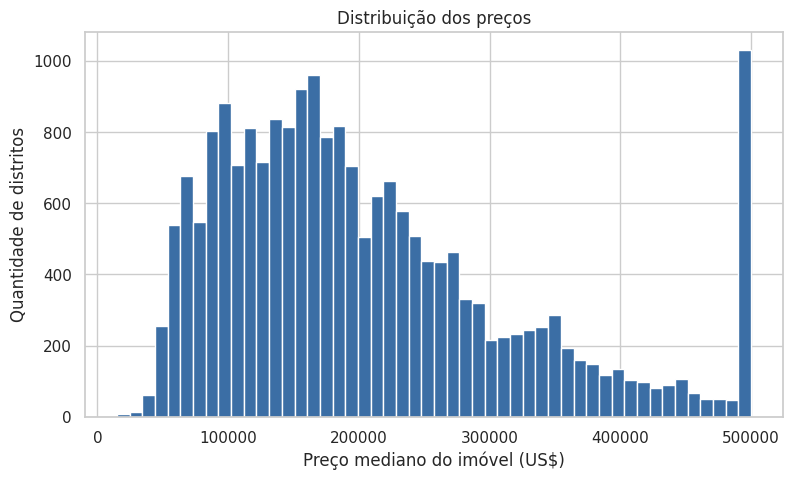

Distritos no teto de 500.001: 965 (4.68%)


In [8]:
ALVO = "median_house_value"

plt.figure(figsize=(9, 5))
plt.hist(df[ALVO], bins=50, color="#3b6ea5", edgecolor="white")
plt.xlabel("Preço mediano do imóvel (US$)")
plt.ylabel("Quantidade de distritos")
plt.title("Distribuição dos preços")
plt.show()

print("Distritos no teto de 500.001:", (df[ALVO] >= 500001).sum(),
      f"({(df[ALVO] >= 500001).mean()*100:.2f}%)")

A distribuição é assimétrica à direita, concentrada entre ~100 mil e ~250 mil dólares. A barra isolada no extremo direito são os distritos com valor **limitado em 500.001** (teto da pesquisa): o preço real desses distritos é desconhecido, só se sabe que é maior ou igual ao teto.

### Gráfico 2 — Boxplots

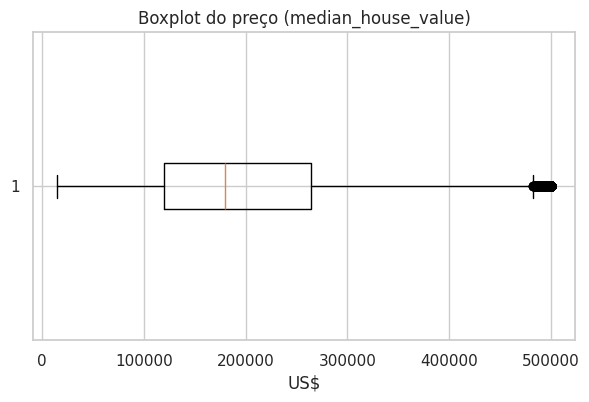

In [9]:
plt.figure(figsize=(7, 4))
plt.boxplot(df[ALVO].dropna(), vert=False)
plt.title("Boxplot do preço (median_house_value)")
plt.xlabel("US$")
plt.show()

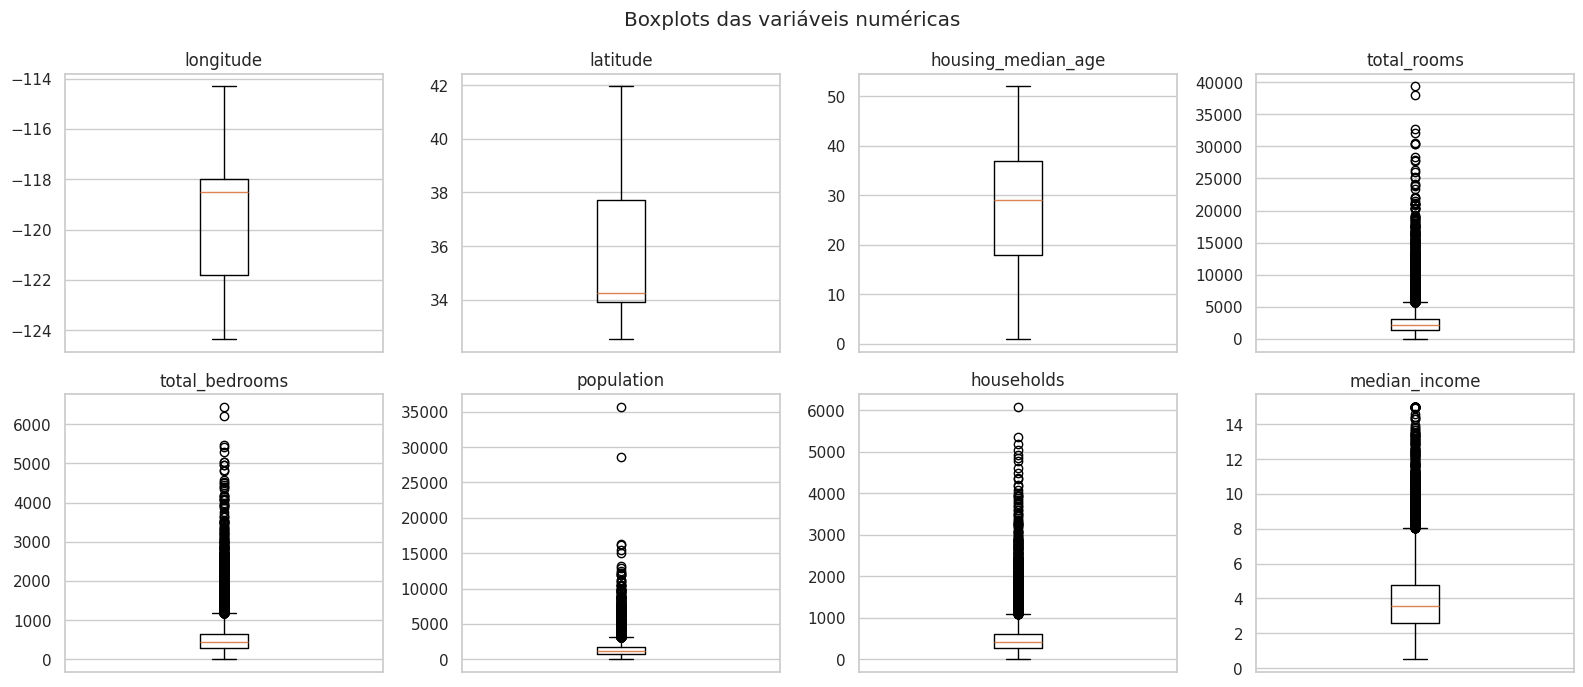

In [10]:
# Boxplots das demais variáveis numéricas
outras = [c for c in colunas_numericas if c != ALVO]
fig, eixos = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(eixos.ravel(), outras):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_xticks([])
plt.suptitle("Boxplots das variáveis numéricas")
plt.tight_layout()
plt.show()

`total_rooms`, `total_bedrooms`, `population` e `households` têm uma grande quantidade de pontos acima do limite superior; `median_income` e o próprio preço também têm valores extremos no lado alto. `longitude`, `latitude` e `housing_median_age` não apresentam outliers.

### Gráfico 3 — Correlação

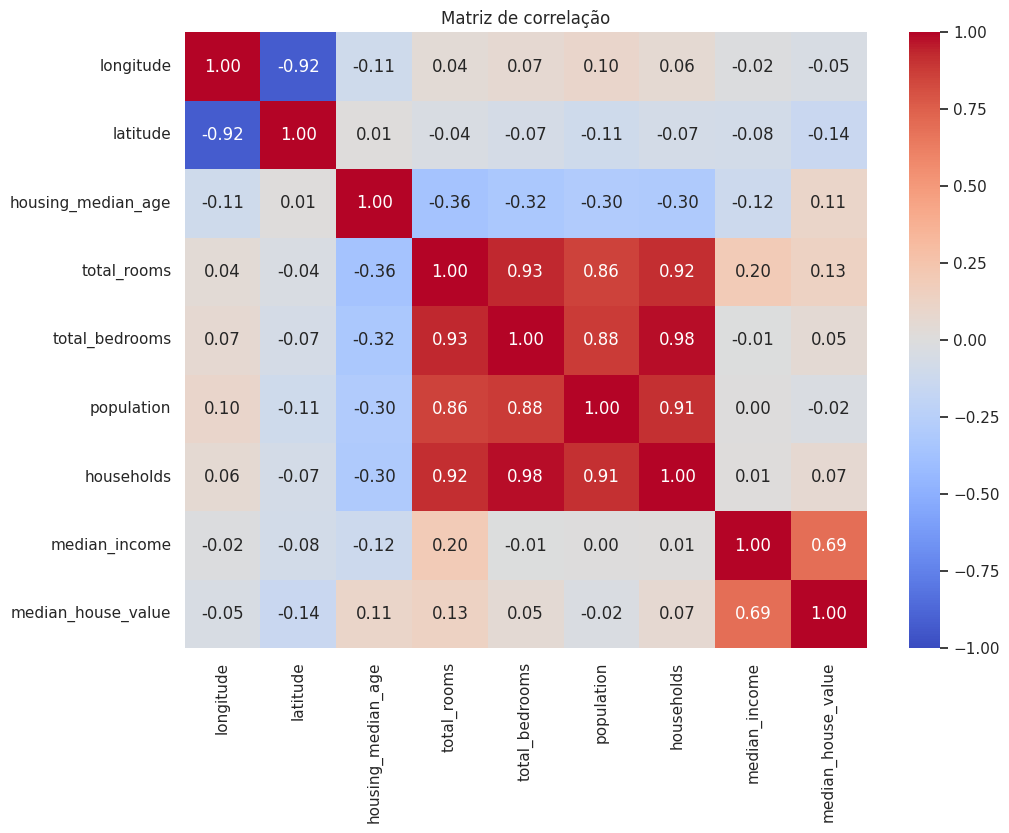

Correlação de cada variável com o preço:
median_house_value    1.0000
median_income         0.6881
total_rooms           0.1342
housing_median_age    0.1056
households            0.0658
total_bedrooms        0.0497
population           -0.0246
longitude            -0.0460
latitude             -0.1442
Name: median_house_value, dtype: float64


In [11]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlação")
plt.show()

print("Correlação de cada variável com o preço:")
print(df.corr(numeric_only=True)[ALVO].sort_values(ascending=False))

- **Mais correlacionada com o preço:** `median_income` (≈ 0,69), muito à frente das demais.
- **Pouco correlacionadas (linearmente):** `population`, `longitude`, `total_bedrooms`, `households` (|r| < 0,07), além de `housing_median_age`, `total_rooms` e `latitude` (|r| entre 0,10 e 0,15). Correlação linear baixa não significa que a variável é inútil: a localização tem efeito claramente não linear, que um kernel RBF consegue capturar.
- **Redundantes entre si:** `total_rooms`, `total_bedrooms`, `population` e `households` têm correlação entre 0,86 e 0,98 — todas medem o "tamanho" do distrito. `latitude` e `longitude` também são fortemente correlacionadas (≈ −0,92) por causa do formato do estado.

Como as contagens brutas dizem pouco sobre o preço, faz sentido combiná-las em **razões** (cômodos por domicílio, pessoas por domicílio, quartos por cômodo) — isso é feito no desafio extra de *feature engineering*.

## Etapa 3 — Identificação de outliers

Método utilizado: **IQR (Intervalo Interquartil)**. Um valor é considerado outlier quando está abaixo de `Q1 − 1,5·IQR` ou acima de `Q3 + 1,5·IQR`. Nesta etapa os outliers são apenas **identificados**; nada é removido.

In [12]:
def limites_iqr(serie):
    # Retorna os limites inferior e superior pelo método do IQR
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

def tabela_outliers(dados, colunas):
    # Monta a tabela com quantidade, percentual, mínimo e máximo de cada variável
    linhas = []
    for col in colunas:
        serie = dados[col].dropna()
        li, ls = limites_iqr(serie)
        qtd = ((serie < li) | (serie > ls)).sum()
        linhas.append({
            "variável": col,
            "mínimo": serie.min(),
            "máximo": serie.max(),
            "limite inferior": li,
            "limite superior": ls,
            "outliers": qtd,
            "% outliers": 100 * qtd / len(serie),
            "método": "IQR (1,5)",
        })
    return pd.DataFrame(linhas).set_index("variável")

relatorio_outliers = tabela_outliers(df, colunas_numericas)
relatorio_outliers

,mínimo,máximo,limite inferior,limite superior,outliers,% outliers,método
variável,,,,,,,
longitude,-124.3500,-114.3100,-127.4850,-112.3250,0,0.0000,"IQR (1,5)"
latitude,32.5400,41.9500,28.2600,43.3800,0,0.0000,"IQR (1,5)"
housing_median_age,1.0000,52.0000,-10.5000,65.5000,0,0.0000,"IQR (1,5)"
total_rooms,2.0000,"39,320.0000","-1,102.6250","5,698.3750",1287,6.2355,"IQR (1,5)"
total_bedrooms,1.0000,"6,445.0000",-230.5000,"1,173.5000",1271,6.2203,"IQR (1,5)"
population,3.0000,"35,682.0000",-620.0000,"3,132.0000",1196,5.7946,"IQR (1,5)"
households,1.0000,"6,082.0000",-207.5000,"1,092.5000",1220,5.9109,"IQR (1,5)"
median_income,0.4999,15.0001,-0.7064,8.0130,681,3.2994,"IQR (1,5)"
median_house_value,"14,999.0000","500,001.0000","-98,087.5000","482,412.5000",1071,5.1890,"IQR (1,5)"


In [13]:
# Olhando os casos mais extremos antes de decidir o que fazer com eles
print("Distritos com maior população:")
print(df.nlargest(5, "population")[["population", "households", "total_rooms", "median_income", ALVO]])
print()
pessoas_por_domicilio = df["population"] / df["households"]
print("Maiores valores de pessoas por domicílio:")
print(pessoas_por_domicilio.nlargest(5))

Distritos com maior população:
       population  households  total_rooms  median_income  median_house_value
15360 35,682.0000  4,769.0000  25,135.0000         2.5729        134,400.0000
9880  28,566.0000  6,082.0000  32,627.0000         2.3087        118,800.0000
13139 16,305.0000  5,358.0000  39,320.0000         4.9516        153,700.0000
10309 16,122.0000  5,189.0000  37,937.0000         7.4947        366,300.0000
6057  15,507.0000  5,050.0000  32,054.0000         6.0191        253,900.0000

Maiores valores de pessoas por domicílio:
19006   1,243.3333
3364      599.7143
16669     502.4615
13034     230.1724
9172       83.1714
dtype: float64


**Leitura dos resultados**

- As quatro variáveis de tamanho (`total_rooms`, `total_bedrooms`, `population`, `households`) têm entre ~5,8% e ~6,3% de outliers, todos no lado superior. São distritos reais, porém muito maiores que o normal.
- `median_income` tem ~3,3% de outliers (distritos de renda alta).
- `median_house_value` tem ~5,2% de outliers pelo IQR; quase todos são os distritos no teto de 500.001.
- `longitude`, `latitude` e `housing_median_age` não têm outliers.
- Alguns distritos têm mais de 500 e até 1.243 pessoas por domicílio — valor incompatível com residências comuns (provavelmente presídios, alojamentos ou instituições).

## Etapa 4 — Tratamento dos outliers

A decisão foi tomada **variável por variável**, sem remover nenhuma linha do banco:

| Variável | Decisão | Justificativa |
|---|---|---|
| `total_rooms`, `total_bedrooms`, `population`, `households` | **Opção B — capping** nos limites do IQR | São distritos reais, então não faz sentido excluí-los. Porém os valores extremos (até 15× o 3º quartil) esticam a escala dessas variáveis e distorcem as distâncias usadas pelo kernel do SVR. Limitar o valor preserva o registro e a informação "distrito grande". |
| Razões criadas no desafio extra (`rooms_per_household`, `bedrooms_per_room`, `population_per_household`) | **Opção B — capping** | Há valores claramente anômalos (ex.: 1.243 pessoas por domicílio), que não representam residências comuns. |
| `median_income` | **Opção C — manter** | Renda alta é característica real e é a variável mais informativa para o preço. Nos testes abaixo, limitar a renda piorou o modelo. |
| `median_house_value` (alvo) | **Opção C — manter** | Os valores altos são imóveis reais (limitados pelo teto de 500.001). Remover ~5% do banco apenas para aumentar o R² não é justificável, e alterar o alvo do teste invalidaria a avaliação. |
| `longitude`, `latitude`, `housing_median_age` | Nada a tratar | Não apresentaram outliers. |

Como nenhuma linha é removida, **o conjunto de teste é exatamente o mesmo em todos os experimentos**, o que torna a comparação entre os modelos justa.

In [14]:
COLUNAS_TAMANHO = ["total_rooms", "total_bedrooms", "population", "households"]
COLUNAS_RAZAO = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]

def aplicar_capping(dados, colunas):
    # Opção B: substitui os valores fora dos limites do IQR pelos próprios limites
    dados = dados.copy()
    for col in colunas:
        li, ls = limites_iqr(dados[col])
        dados[col] = dados[col].clip(lower=li, upper=ls)
    return dados

# Conferência: depois do capping não sobra outlier nas variáveis tratadas e nenhuma linha é perdida
df_teste_cap = aplicar_capping(df.fillna({"total_bedrooms": df["total_bedrooms"].median()}), COLUNAS_TAMANHO)
print("Linhas antes:", len(df), "| linhas depois:", len(df_teste_cap))
tabela_outliers(df_teste_cap, COLUNAS_TAMANHO)[["mínimo", "máximo", "outliers", "% outliers"]]

Linhas antes: 20640 | linhas depois: 20640


,mínimo,máximo,outliers,% outliers
variável,,,,
total_rooms,2.0000,"5,698.3750",0,0.0000
total_bedrooms,1.0000,"1,162.6250",0,0.0000
population,3.0000,"3,132.0000",0,0.0000
households,1.0000,"1,092.5000",0,0.0000


## Etapa 5 — Preparação dos dados

A função abaixo concentra todo o tratamento, com cada passo podendo ser ligado ou desligado. Assim é possível medir o efeito de cada tratamento separadamente (Etapas 11 e 12).

- **Valores ausentes:** `total_bedrooms` preenchido pela mediana.
- **Variável categórica:** `ocean_proximity` transformada em colunas numéricas com `pd.get_dummies()` (one-hot).
- **Outliers:** capping pelo IQR nas colunas indicadas.
- **Novas características (desafio extra):** razões entre as contagens.

In [15]:
def preparar_dados(dados, imputar=True, dummies=True, capping=None, novas_variaveis=False):
    # Devolve X (variáveis independentes) e y (variável dependente) já tratados
    dados = dados.copy()

    # 1) Valores ausentes -> mediana
    if imputar:
        dados["total_bedrooms"] = dados["total_bedrooms"].fillna(dados["total_bedrooms"].median())
    else:
        # sem tratamento: a coluna com nulos não pode ser usada pelo SVR
        dados = dados.drop(columns=["total_bedrooms"])

    # 2) Feature engineering (desafio extra)
    if novas_variaveis:
        dados["rooms_per_household"] = dados["total_rooms"] / dados["households"]
        dados["bedrooms_per_room"] = dados["total_bedrooms"] / dados["total_rooms"]
        dados["population_per_household"] = dados["population"] / dados["households"]

    # 3) Outliers -> capping pelo IQR
    if capping:
        dados = aplicar_capping(dados, [c for c in capping if c in dados.columns])

    # 4) Variável categórica -> numérica
    if dummies:
        dados = pd.get_dummies(dados, columns=["ocean_proximity"], dtype=float)
    else:
        dados = dados.drop(columns=["ocean_proximity"])

    X = dados.drop(ALVO, axis=1)
    y = dados[ALVO]
    return X, y

X, y = preparar_dados(df, capping=COLUNAS_TAMANHO)
print("X:", X.shape, "| y:", y.shape)
X.head()

X: (20640, 13) | y: (20640,)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.2300,37.8800,41.0000,880.0000,129.0000,322.0000,126.0000,8.3252,0.0000,0.0000,0.0000,1.0000,0.0000
1,-122.2200,37.8600,21.0000,"5,698.3750","1,106.0000","2,401.0000","1,092.5000",8.3014,0.0000,0.0000,0.0000,1.0000,0.0000
2,-122.2400,37.8500,52.0000,"1,467.0000",190.0000,496.0000,177.0000,7.2574,0.0000,0.0000,0.0000,1.0000,0.0000
3,-122.2500,37.8500,52.0000,"1,274.0000",235.0000,558.0000,219.0000,5.6431,0.0000,0.0000,0.0000,1.0000,0.0000
4,-122.2500,37.8500,52.0000,"1,627.0000",280.0000,565.0000,259.0000,3.8462,0.0000,0.0000,0.0000,1.0000,0.0000


## Etapas 6 e 7 — Separação treino/teste e padronização

- Divisão **80% treino / 20% teste** com `random_state=42`.
- `StandardScaler` ajustado (**fit**) **somente no treino** e depois aplicado no teste, para não vazar informação do teste.

A função abaixo faz a divisão, a padronização, o treinamento e a avaliação, e é reutilizada em todos os experimentos. Ela também permite padronizar a **variável alvo** (usando apenas o `y_train`), o que será importante mais adiante; as previsões são sempre convertidas de volta para dólares antes de calcular as métricas.

In [16]:
def dividir_e_padronizar(X, y, padronizar_X=True):
    # Etapa 6: divisão treino/teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42
    )
    # Etapa 7: padronização (fit somente no treino)
    if padronizar_X:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test

def treinar_e_avaliar(X, y, modelo, padronizar_X=True, alvo="original"):
    # alvo = "original"   -> y em dólares, sem transformação
    # alvo = "padronizado" -> y padronizado com StandardScaler (fit no treino)
    # alvo = "log"        -> log(y) padronizado
    X_train, X_test, y_train, y_test = dividir_e_padronizar(X, y, padronizar_X)

    if alvo == "original":
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
    else:
        y_tr = np.log(y_train) if alvo == "log" else y_train
        scaler_y = StandardScaler()
        y_tr = scaler_y.fit_transform(y_tr.values.reshape(-1, 1)).ravel()
        modelo.fit(X_train, y_tr)
        y_pred = scaler_y.inverse_transform(modelo.predict(X_test).reshape(-1, 1)).ravel()
        if alvo == "log":
            y_pred = np.exp(y_pred)

    return {
        "R²": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "y_test": y_test,
        "y_pred": y_pred,
        "modelo": modelo,
    }

X_train, X_test, y_train, y_test = dividir_e_padronizar(X, y)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Média das colunas de treino após padronização ≈", X_train.mean(axis=0).round(3).max())
print("Desvio-padrão das colunas de treino ≈", X_train.std(axis=0).round(3).max())

Treino: (16512, 13) | Teste: (4128, 13)
Média das colunas de treino após padronização ≈ -0.0
Desvio-padrão das colunas de treino ≈ 1.0


## Etapa 8 — Primeiro modelo SVR (baseline)

Modelo inicial: `SVR()` com os parâmetros padrão (kernel RBF, `C=1`, `epsilon=0.1`), sobre os dados **sem tratamento** — apenas as colunas numéricas completas (sem `total_bedrooms`, que tem nulos, e sem `ocean_proximity`, que é texto), sem padronização.

In [17]:
resultados = []   # guarda todos os experimentos do trabalho

def registrar(nome, tratamento, res, kernel="rbf", C=1, epsilon=0.1, gamma="scale"):
    resultados.append({
        "Modelo": nome, "Tratamento": tratamento, "Kernel": kernel,
        "C": C, "Epsilon": epsilon, "Gamma": gamma,
        "R²": res["R²"], "MAE": res["MAE"], "RMSE": res["RMSE"],
    })
    print(f"{nome}: R² = {res['R²']:.4f} | MAE = {res['MAE']:,.0f} | RMSE = {res['RMSE']:,.0f}")

X_base, y_base = preparar_dados(df, imputar=False, dummies=False)
res_baseline = treinar_e_avaliar(X_base, y_base, SVR(), padronizar_X=False)
registrar("1 - Baseline", "Nenhum (dados originais)", res_baseline)

1 - Baseline: R² = -0.0486 | MAE = 87,341 | RMSE = 117,222


O baseline tem **R² negativo**: ele é pior do que simplesmente prever a média dos preços para todos os distritos. O SVR padrão, sobre dados em escalas muito diferentes, praticamente não aprende nada.

## Etapa 12 — Comparação antes e depois de cada tratamento

Cada modelo abaixo acrescenta **um** tratamento em relação ao anterior, sempre com `SVR()` padrão e o mesmo conjunto de teste. *(Esta etapa aparece antes da otimização porque os tratamentos definem os dados que serão otimizados.)*

In [18]:
# Modelo 2: tratamento de valores ausentes (mediana) + variável categórica convertida
X2, y2 = preparar_dados(df)
res2 = treinar_e_avaliar(X2, y2, SVR(), padronizar_X=False)
registrar("2 - Valores ausentes", "Mediana em total_bedrooms + get_dummies", res2)

# Modelo 3: + tratamento de outliers (capping IQR)
X3, y3 = preparar_dados(df, capping=COLUNAS_TAMANHO)
res3 = treinar_e_avaliar(X3, y3, SVR(), padronizar_X=False)
registrar("3 - Outliers", "Anterior + capping IQR", res3)

# Modelo 4: + padronização das variáveis independentes
res4 = treinar_e_avaliar(X3, y3, SVR(), padronizar_X=True)
registrar("4 - Padronização de X", "Anterior + StandardScaler em X", res4)

2 - Valores ausentes: R² = -0.0487 | MAE = 87,344 | RMSE = 117,229
3 - Outliers: R² = -0.0482 | MAE = 87,325 | RMSE = 117,197
4 - Padronização de X: R² = -0.0424 | MAE = 86,965 | RMSE = 116,874


Mesmo com valores ausentes tratados, outliers tratados e `X` padronizado, o R² continua próximo de zero. O motivo está na **escala da variável alvo**: os preços estão em centenas de milhares de dólares, e os parâmetros padrão do SVR (`C=1`, `epsilon=0.1`) são minúsculos perante essa escala. Com `C=1` a penalização dos erros é tão fraca que o modelo fica quase constante.

Há duas saídas equivalentes: usar valores de `C` enormes, ou **padronizar também a variável alvo** (transformação do alvo, sugerida no desafio extra). A segunda é mais limpa, porque deixa `C` e `epsilon` em faixas normais. A padronização do alvo é ajustada só com `y_train`, e as métricas continuam sendo calculadas em dólares.

In [19]:
# Modelo 5: + padronização da variável alvo
res5 = treinar_e_avaliar(X3, y3, SVR(), alvo="padronizado")
registrar("5 - Padronização de X e y", "Anterior + StandardScaler no alvo", res5)

# Modelo 6: + novas características (razões) com capping
X6, y6 = preparar_dados(df, capping=COLUNAS_TAMANHO + COLUNAS_RAZAO, novas_variaveis=True)
res6 = treinar_e_avaliar(X6, y6, SVR(), alvo="padronizado")
registrar("6 - Feature engineering", "Anterior + razões por domicílio", res6)

5 - Padronização de X e y: R² = 0.7507 | MAE = 37,893 | RMSE = 57,158
6 - Feature engineering: R² = 0.7690 | MAE = 36,740 | RMSE = 55,023


### O tratamento de outliers ajudou?

Nos modelos 2 → 3 o efeito do capping não aparece, porque o modelo ainda não estava aprendendo. Para medir o efeito de verdade, o teste abaixo compara **com e sem** tratamento de outliers já com os dados padronizados, mudando apenas esse fator.

In [20]:
def r2_rapido(**opcoes):
    Xa, ya = preparar_dados(df, **opcoes)
    return treinar_e_avaliar(Xa, ya, SVR(), alvo="padronizado")["R²"]

efeito_outliers = pd.DataFrame([
    {"Variáveis": "originais", "Outliers": "mantidos (sem tratamento)", "R²": r2_rapido()},
    {"Variáveis": "originais", "Outliers": "capping nas contagens", "R²": res5["R²"]},
    {"Variáveis": "originais", "Outliers": "capping nas contagens + median_income", "R²": r2_rapido(capping=COLUNAS_TAMANHO + ["median_income"])},
    {"Variáveis": "originais + razões", "Outliers": "mantidos (sem tratamento)", "R²": r2_rapido(novas_variaveis=True)},
    {"Variáveis": "originais + razões", "Outliers": "capping nas contagens e razões", "R²": res6["R²"]},
])
efeito_outliers

,Variáveis,Outliers,R²
0,originais,mantidos (sem tratamento),0.7458
1,originais,capping nas contagens,0.7507
2,originais,capping nas contagens + median_income,0.7471
3,originais + razões,mantidos (sem tratamento),0.7458
4,originais + razões,capping nas contagens e razões,0.7690


- O capping das contagens melhora o R² em relação a manter os outliers.
- Aplicar capping também em `median_income` **piora** o resultado — por isso a renda foi mantida (Opção C).
- As novas razões **só ajudam quando os outliers delas são tratados**: sem capping, valores como 1.243 pessoas por domicílio dominam a escala da coluna e o ganho desaparece.

## Etapa 9 — Otimização: testando diferentes kernels

Dados utilizados daqui em diante: valores ausentes tratados, capping, novas características, `X` e `y` padronizados. Todos os kernels usam `C=1` e `epsilon=0.1`.

In [21]:
comparacao_kernels = []
for kernel in ["linear", "rbf", "poly", "sigmoid"]:
    res = treinar_e_avaliar(X6, y6, SVR(kernel=kernel), alvo="padronizado")
    comparacao_kernels.append({"Kernel": kernel, "R²": res["R²"], "MAE": res["MAE"], "RMSE": res["RMSE"]})
    print(f"kernel = {kernel:8s} R² = {res['R²']:.4f}")

comparacao_kernels = pd.DataFrame(comparacao_kernels).set_index("Kernel")
comparacao_kernels

kernel = linear   R² = 0.6382
kernel = rbf      R² = 0.7690
kernel = poly     R² = 0.7066
kernel = sigmoid  R² = -9923.8886


,R²,MAE,RMSE
Kernel,,,
linear,0.6382,"47,963.9124","68,852.5191"
rbf,0.7690,"36,740.0179","55,022.7710"
poly,0.7066,"40,817.9685","62,006.6487"
sigmoid,"-9,923.8886","7,203,948.1130","11,404,237.4424"


O kernel **RBF** teve o melhor resultado, seguido do polinomial; o linear fica abaixo porque a relação entre localização e preço não é linear, e o sigmoid não é adequado para estes dados.

## Etapa 10 — Otimização dos hiperparâmetros (GridSearchCV)

Busca em grade com validação cruzada de 5 partes (`cv=5`, `scoring="r2"`), usando **somente os dados de treino**.

Duas adaptações em relação ao exemplo do enunciado, para o tempo de execução ficar viável (o custo do SVR cresce mais que quadraticamente com o número de amostras):

1. a busca é feita em uma **amostra aleatória de 5.000 registros do treino**; o melhor conjunto de parâmetros é depois treinado no treino completo;
2. o kernel linear é testado com `C` até 10 (ele já se mostrou inferior e fica muito lento com `C` alto).

Como `X` está padronizado, `gamma="scale"` e `gamma="auto"` dão praticamente o mesmo valor (≈ 1/nº de variáveis), então foram incluídos também valores numéricos de `gamma`.

> **Atenção:** esta célula leva alguns minutos para rodar (cerca de 7 minutos com 2 núcleos).

In [22]:
X_train, X_test, y_train, y_test = dividir_e_padronizar(X6, y6)

# Padronização do alvo (fit somente no treino)
scaler_y = StandardScaler()
y_train_pad = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# Amostra do treino para a busca
rng = np.random.RandomState(42)
amostra = rng.choice(len(X_train), size=5000, replace=False)

parametros = [
    {"kernel": ["rbf"],
     "C": [0.1, 1, 10, 100],
     "epsilon": [0.01, 0.1, 0.2, 0.5],
     "gamma": ["scale", "auto", 0.1, 0.2]},
    {"kernel": ["linear"],
     "C": [0.1, 1, 10],
     "epsilon": [0.01, 0.1, 0.2, 0.5]},
]

grid = GridSearchCV(SVR(), parametros, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train[amostra], y_train_pad[amostra])

print("Melhores parâmetros:", grid.best_params_)
print(f"Melhor R² médio na validação cruzada: {grid.best_score_:.4f}")

Melhores parâmetros: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}
Melhor R² médio na validação cruzada: 0.7712


In [23]:
# As 10 melhores combinações encontradas
ranking = pd.DataFrame(grid.cv_results_)[
    ["param_kernel", "param_C", "param_epsilon", "param_gamma", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score").head(10)
ranking

,param_kernel,param_C,param_epsilon,param_gamma,mean_test_score,std_test_score,rank_test_score
40,rbf,10.0000,0.2000,scale,0.7712,0.0262,1
41,rbf,10.0000,0.2000,auto,0.7711,0.0263,2
36,rbf,10.0000,0.1000,scale,0.7700,0.0271,3
37,rbf,10.0000,0.1000,auto,0.7692,0.0269,4
32,rbf,10.0000,0.0100,scale,0.7677,0.0256,5
33,rbf,10.0000,0.0100,auto,0.7665,0.0253,6
26,rbf,1.0000,0.2000,0.1000,0.7664,0.0215,7
22,rbf,1.0000,0.1000,0.1000,0.7661,0.0222,8
18,rbf,1.0000,0.0100,0.1000,0.7653,0.0222,9
25,rbf,1.0000,0.2000,auto,0.7636,0.0224,10


In [24]:
# Modelo final: melhores parâmetros treinados no conjunto de treino COMPLETO
melhores = grid.best_params_
modelo_final = SVR(**melhores)
modelo_final.fit(X_train, y_train_pad)

# Previsão no teste, convertida de volta para dólares
y_pred = scaler_y.inverse_transform(modelo_final.predict(X_test).reshape(-1, 1)).ravel()

r2 = r2_score(y_test, y_pred)
print(f"R² final (teste): {r2:.4f}")

R² final (teste): 0.7808


### Desafio extra — transformação logarítmica do alvo

Como o preço é assimétrico, foi testado também treinar o mesmo modelo sobre `log(preço)` (padronizado), convertendo a previsão de volta com a exponencial.

In [25]:
res_log = treinar_e_avaliar(X6, y6, SVR(**melhores), alvo="log")
print(f"Alvo padronizado      -> R² = {r2:.4f}")
print(f"Alvo em log + padrão. -> R² = {res_log['R²']:.4f} | MAE = {res_log['MAE']:,.0f} | RMSE = {res_log['RMSE']:,.0f}")

Alvo padronizado      -> R² = 0.7808
Alvo em log + padrão. -> R² = 0.7788 | MAE = 35,454 | RMSE = 53,844


## Etapa 13 — Avaliação final

Métricas do modelo final, calculadas no **conjunto de teste** (dados que não participaram do treinamento nem da busca de hiperparâmetros).

In [26]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² no treino apenas para verificar sobreajuste (não é a métrica de avaliação)
y_pred_treino = scaler_y.inverse_transform(modelo_final.predict(X_train).reshape(-1, 1)).ravel()
r2_treino = r2_score(y_train, y_pred_treino)

print("Hiperparâmetros do modelo final:", melhores)
print(f"R²   (teste): {r2:.4f}")
print(f"MAE  (teste): US$ {mae:,.2f}")
print(f"RMSE (teste): US$ {rmse:,.2f}")
print(f"R²  (treino): {r2_treino:.4f}")
print("Vetores de suporte:", len(modelo_final.support_), "de", len(X_train), "amostras de treino")
print()
print("Requisito R² > 0,65 atingido?", "SIM" if r2 > 0.65 else "NÃO")

res_final = {"R²": r2, "MAE": mae, "RMSE": rmse}
registrar("7 - Modelo final", "Anterior + GridSearchCV", res_final, kernel=melhores["kernel"],
          C=melhores["C"], epsilon=melhores["epsilon"], gamma=melhores.get("gamma", "-"))

Hiperparâmetros do modelo final: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}
R²   (teste): 0.7808
MAE  (teste): US$ 35,931.50
RMSE (teste): US$ 53,599.56
R²  (treino): 0.8280
Vetores de suporte: 8159 de 16512 amostras de treino

Requisito R² > 0,65 atingido? SIM
7 - Modelo final: R² = 0.7808 | MAE = 35,932 | RMSE = 53,600


## Etapa 14 — Gráfico Real × Predito

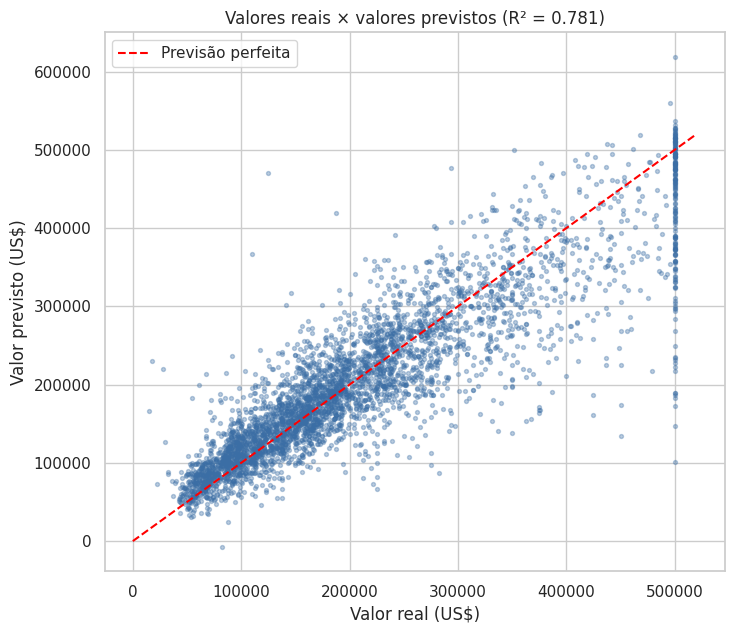

In [27]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred, s=8, alpha=0.35, color="#3b6ea5")
limite = [0, 520000]
plt.plot(limite, limite, color="red", linestyle="--", label="Previsão perfeita")
plt.xlabel("Valor real (US$)")
plt.ylabel("Valor previsto (US$)")
plt.title(f"Valores reais × valores previstos (R² = {r2:.3f})")
plt.legend()
plt.show()

Os pontos se concentram em torno da diagonal, ou seja, na maior parte dos distritos a previsão fica próxima do valor real. Dois padrões chamam atenção:

- a nuvem se abre conforme o preço aumenta: o erro é maior nos imóveis caros;
- a **faixa vertical em 500.001** são os distritos com preço censurado no teto. O modelo prevê valores variados para eles (em geral abaixo do teto), pois o valor real desses imóveis não está registrado no banco. Esses pontos são a principal fonte de erro do modelo.

## Etapa 11 — Tabela de experimentos

Todos os experimentos realizados, na ordem em que foram feitos (mesmo conjunto de teste em todos).

In [28]:
tabela_experimentos = pd.DataFrame(resultados)
tabela_experimentos

,Modelo,Tratamento,Kernel,C,Epsilon,Gamma,R²,MAE,RMSE
0,1 - Baseline,Nenhum (dados originais),rbf,1,0.1000,scale,-0.0486,"87,340.6137","117,222.0000"
1,2 - Valores ausentes,Mediana em total_bedrooms + get_dummies,rbf,1,0.1000,scale,-0.0487,"87,344.1949","117,229.2477"
2,3 - Outliers,Anterior + capping IQR,rbf,1,0.1000,scale,-0.0482,"87,325.0077","117,196.7798"
3,4 - Padronização de X,Anterior + StandardScaler em X,rbf,1,0.1000,scale,-0.0424,"86,965.2064","116,874.1773"
4,5 - Padronização de X e y,Anterior + StandardScaler no alvo,rbf,1,0.1000,scale,0.7507,"37,892.5490","57,158.3848"
5,6 - Feature engineering,Anterior + razões por domicílio,rbf,1,0.1000,scale,0.7690,"36,740.0179","55,022.7710"
6,7 - Modelo final,Anterior + GridSearchCV,rbf,10,0.2000,scale,0.7808,"35,931.5002","53,599.5560"


In [29]:
# Tabela resumida no formato pedido na Etapa 12
tabela_experimentos[["Modelo", "Tratamento", "R²"]].round(4)

,Modelo,Tratamento,R²
0,1 - Baseline,Nenhum (dados originais),-0.0486
1,2 - Valores ausentes,Mediana em total_bedrooms + get_dummies,-0.0487
2,3 - Outliers,Anterior + capping IQR,-0.0482
3,4 - Padronização de X,Anterior + StandardScaler em X,-0.0424
4,5 - Padronização de X e y,Anterior + StandardScaler no alvo,0.7507
5,6 - Feature engineering,Anterior + razões por domicílio,0.7690
6,7 - Modelo final,Anterior + GridSearchCV,0.7808


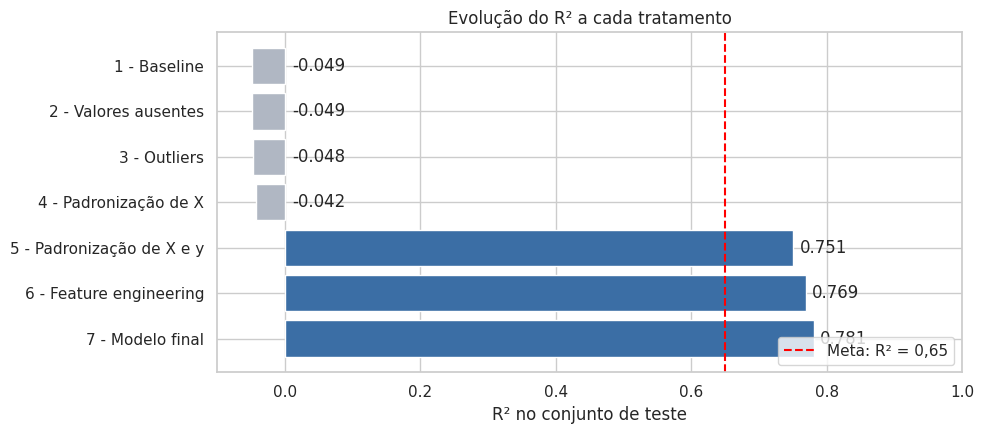

In [30]:
plt.figure(figsize=(10, 4.5))
cores = ["#b0b7c3" if v < 0.65 else "#3b6ea5" for v in tabela_experimentos["R²"]]
plt.barh(tabela_experimentos["Modelo"], tabela_experimentos["R²"], color=cores)
plt.axvline(0.65, color="red", linestyle="--", label="Meta: R² = 0,65")
for i, v in enumerate(tabela_experimentos["R²"]):
    plt.text(max(v, 0) + 0.01, i, f"{v:.3f}", va="center")
plt.gca().invert_yaxis()
plt.xlim(-0.1, 1.0)
plt.xlabel("R² no conjunto de teste")
plt.title("Evolução do R² a cada tratamento")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Conclusão

1. **O modelo atingiu R² > 0,65?** Sim. O modelo final obteve **R² = 0,7808** no conjunto de teste (MAE ≈ US$ 35.932; RMSE ≈ US$ 53.600).
2. **Qual tratamento teve maior impacto?** A **padronização**, em especial a da variável alvo: o R² saiu de -0,0424 para 0,7507. Com o preço em centenas de milhares de dólares, o SVR com `C=1` praticamente não aprende.
3. **O tratamento de outliers melhorou o resultado?** Sim, de forma moderada: com os dados padronizados, o capping das contagens elevou o R² de 0,7458 para 0,7507, e foi ele que permitiu o ganho das novas razões (0,7458 sem capping contra 0,7690 com capping). Já limitar `median_income` piorou o modelo, e por isso a renda foi mantida.
4. **Qual kernel foi melhor?** O **RBF** (0,7690), à frente do polinomial (0,7066) e do linear (0,6382).
5. **Hiperparâmetros do modelo final:** `kernel="rbf"`, `C=10`, `epsilon=0.2`, `gamma="scale"`.
6. **Dificuldades:** a escala do alvo (que derruba o R² do SVR padrão), o tempo de treinamento do SVR com ~16,5 mil amostras (o que exigiu fazer o GridSearch em uma amostra do treino) e os preços censurados em 500.001, que o modelo não tem como prever corretamente.
7. **Poderia ser melhorado?** Sim: grade mais fina de `C` e `gamma` com o treino completo, novas variáveis de localização (distância a grandes cidades, agrupamento de coordenadas), tratamento específico para os distritos censurados e uso de `Pipeline` para que a mediana e os limites do capping também sejam calculados só com o treino.